# Import library

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import textwrap
warnings.filterwarnings('ignore')

# Statistical Analysis
from scipy.stats import mannwhitneyu, ks_2samp, chi2_contingency

# Machine Learning Library
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, recall_score,
                             mean_squared_error, confusion_matrix, precision_score)

# Imbalance data
from imblearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.calibration import CalibrationDisplay
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Configure parameter
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Python Libraries Initialized Successfully!")
print("Constant parameters:", RANDOM_STATE)

Python Libraries Initialized Successfully!
Constant parameters: 42


# EDA - Exploratory Data Analysis

**1. Load data**

In [23]:
# Load dataset
print("=" * 10, "DATA OVERVIEW", "=" * 10)

DATA_DIR = "/content/drive/MyDrive/Viettel Dataset Customers/Dataset"
print("List of data:", os.listdir(DATA_DIR))

# Read metadata and main dataset
sheets_path = os.path.join(DATA_DIR, "Danh_sach_truong_bai_1.xlsx")
txt_path = os.path.join(DATA_DIR, "junction_postvip_sum_6mon_enr.txt")

sheets_columns = pd.read_excel(sheets_path)
df_full = pd.read_csv(txt_path, sep='|', header=None)

# Match column between TXT and XLSX file
column_names = sheets_columns["Features"].tolist()
df_full.columns = column_names

# Data information
print(f"\nDataset shape: {df_full.shape}")
memory_usage = df_full.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"Memory usage: {memory_usage:.2f} MB")
print(f"Duplicated rows: {df_full.duplicated().sum()}")

# Data types
print("\nData types of columns:")
print(df_full.dtypes.value_counts())

# Review data
print("\nFirst 5 rows of the dataset:")
display(df_full.head())

# Display column names
print(f"\nTotal number of columns: {len(df_full.columns)}")

cols_str = ", ".join(f'"{c}"' for c in df_full.columns)
wrapped = textwrap.fill(cols_str, width=230)
print(f"Columns: [{wrapped}]")

========== DATA OVERVIEW ==========
List of data: ['junction_postvip_sum_6mon_enr.txt', 'Danh_sach_truong_bai_1.xlsx']

Dataset shape: (919361, 153)
Memory usage: 1073.17 MB
Duplicated rows: 0

Data types of columns:
float64    150
int64        3
Name: count, dtype: int64

First 5 rows of the dataset:


,ID,sum_total_use_charge_tn,sum_total_use_charge_tn_1,sum_total_use_charge_tn_2,sum_total_use_charge_tn_3,sum_total_use_charge_tn_4,sum_total_use_charge_tn_5,sum_total_A s_tn,sum_total_A s_tn_1,sum_total_A s_tn_2,...,sum_M_times_tn_3,sum_M_times_tn_4,sum_M_times_tn_5,sum_M_charge_tn,sum_M_charge_tn_1,sum_M_charge_tn_2,sum_M_charge_tn_3,sum_M_charge_tn_4,sum_M_charge_tn_5,churn
0,2285899345,349688.56,400264.96,366640.87,464489.95,387936.79,364476.79,559.0,682.0,601.0,...,242.0,198.0,178.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2293856355,195987.11,224965.55,182741.57,206699.93,180660.21,183674.34,712.0,857.0,374.0,...,336.0,169.0,138.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,2290588355,316340.62,322837.18,248428.44,240993.57,224259.06,207918.73,2021.0,1773.0,1205.0,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,2216952365,181012.38,175681.86,233540.52,155115.52,152377.36,156420.10,290.0,246.0,252.0,...,25.0,33.0,78.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,2221641375,334968.69,434120.10,253201.41,199496.40,126333.27,102412.77,1671.0,1717.0,1255.0,...,169.0,275.0,188.0,0.0,0.0,0.0,0.0,0.0,0.0,0



Total number of columns: 153
Columns: ["ID", "sum_total_use_charge_tn", "sum_total_use_charge_tn_1", "sum_total_use_charge_tn_2", "sum_total_use_charge_tn_3", "sum_total_use_charge_tn_4", "sum_total_use_charge_tn_5", "sum_total_A s_tn", "sum_total_A s_tn_1",
"sum_total_A s_tn_2", "sum_total_A s_tn_3", "sum_total_A s_tn_4", "sum_total_A s_tn_5", "sum_free_service_fee_tn", "sum_free_service_fee_tn_1", "sum_free_service_fee_tn_2", "sum_free_service_fee_tn_3", "sum_free_service_fee_tn_4",
"sum_free_service_fee_tn_5", "sum_t_A_charge_tn", "sum_t_A_charge_tn_1", "sum_t_A_charge_tn_2", "sum_t_A_charge_tn_3", "sum_t_A_charge_tn_4", "sum_t_A_charge_tn_5", "sum_t_dịch vụ B_charge_tn", "sum_t_dịch vụ B_charge_tn_1",
"sum_t_dịch vụ B_charge_tn_2", "sum_t_dịch vụ B_charge_tn_3", "sum_t_dịch vụ B_charge_tn_4", "sum_t_dịch vụ B_charge_tn_5", "sum_t_dịch vụ B_times_tn", "sum_t_dịch vụ B_times_tn_1", "sum_t_dịch vụ B_times_tn_2", "sum_t_dịch vụ
B_times_tn_3", "sum_t_dịch vụ B_times_tn_4", "sum_t_dịch 

**2. Data Survey**

In [24]:
print("=" * 10, "TARGET VARIABLES SURVEYS", "=" * 10)

target_columns = "churn"
target_loc = df_full[target_columns]

# Target variables analysis (Churn = 1, No churn = 0)
target_loc["churn_percentage"] = (df_full[target_columns] == 1).astype(int)
target_counts = target_loc["churn_percentage"].value_counts()

if 1 in target_counts.index:
    churn_rate = (target_counts[1] / (target_counts[0] + target_counts[1]))
else:
    churn_rate = 0.0
    print("No churned customers found in the dataset.")

print("Target variables:", target_columns)
print("Churn Distribution: ")
print(target_counts)
print(f"Overall Churn Rate: {churn_rate:.4f} ({churn_rate * 100:.2f}%)")

========== TARGET VARIABLES SURVEYS ==========
Target variables: churn
Churn Distribution: 
churn
0    895884
1     23477
Name: count, dtype: int64
Overall Churn Rate: 0.0255 (2.55%)


In [25]:
print("=" * 10, "DATA QUALITY SUMMARY", "=" * 10)

# Missing values analysis in dataset
summary = pd.DataFrame({
    "Data Type": df_full.dtypes,
    "Non-Null Count": df_full.notnull().sum(),
    "Missing_count" : df_full.isnull().sum(),
    "Missing_percentage" : (df_full.isnull().sum() / len(df_full) * 100).round(2),
    "Unique Values": df_full.nunique()
})

print("Missing values summary:")
check_cols = summary[summary["Missing_percentage"] > 0]
if len(check_cols) > 0:
  print(check_cols.head(20))
else:
  print("No missing values")

# Add zero counts (only for numeric)
numeric_cols = df_full.select_dtypes(include=[np.number]).columns
zero_counts = {col: (df_full[col] == 0.0).sum() if col in numeric_cols else np.nan for col in df_full.columns}
summary["Zero Count"] = pd.Series(zero_counts)
summary["Zero %"] = round(summary["Zero Count"] / len(df_full) * 100, 2)

# Identify constant columns
summary["Is Constant"] = summary["Unique Values"] == 1

# Sort by Missing % for easier reading
summary = summary.sort_values(by="Missing_percentage", ascending=False)
display(summary.head(10))

total_missing = df_full.isnull().sum().sum() # Sum the Series to get a single value
total_percent = (total_missing / df_full.size) * 100 # Calculate the overall percentage
print(f"\n🔍 Total missing cells: {total_missing:,} ({total_percent:.2f}% of all data)")
print("=" * 10, "DATA QUALITY CHECK COMPLETED", "=" * 10)

========== DATA QUALITY SUMMARY ==========
Missing values summary:
No missing values


,Data Type,Non-Null Count,Missing_count,Missing_percentage,Unique Values,Zero Count,Zero %,Is Constant
ID,int64,919361,0,0.0,919361,0,0.00,False
sum_total_use_charge_tn,float64,919361,0,0.0,808347,18472,2.01,False
sum_total_use_charge_tn_1,float64,919361,0,0.0,812388,12956,1.41,False
sum_total_use_charge_tn_2,float64,919361,0,0.0,815655,12768,1.39,False
sum_total_use_charge_tn_3,float64,919361,0,0.0,816908,12787,1.39,False
sum_total_use_charge_tn_4,float64,919361,0,0.0,812859,13393,1.46,False
sum_total_use_charge_tn_5,float64,919361,0,0.0,816530,14790,1.61,False
sum_total_A s_tn,float64,919361,0,0.0,5462,11626,1.26,False
sum_total_A s_tn_1,float64,919361,0,0.0,5367,6242,0.68,False
sum_total_A s_tn_2,float64,919361,0,0.0,5318,6076,0.66,False



🔍 Total missing cells: 0 (0.00% of all data)
========== DATA QUALITY CHECK COMPLETED ==========


# Feature Categorization

In [26]:
# Feature Categorization and Selection
print("=" * 10, "FEATURE CATEGORIZATION", "=" * 10)

# Define feature group based on business logic
feature_groups = {
    "ID": [], "Demographic": [], "Usage": [], "Charge": [], "Volume": [],
    "Times": [], "Duration": [], "Temporal": [], "Target": [], "Other": []
}

# Categorize each columnns based on its name
for cols in df_full.columns.tolist():
  name = cols.lower()
  if "id" in name:
      feature_groups["ID"].append(cols)
  elif "age" in name or "gender" in name or "province" in name:
      feature_groups["Demographic"].append(cols)
  elif "use" in name or "usage" in name or "total" in name:
      feature_groups["Usage"].append(cols)
  elif "charge" in name or "fee" in name:
      feature_groups["Charge"].append(cols)
  elif "volume" in name:
      feature_groups["Volume"].append(cols)
  elif "time" in name or "times" in name:
      feature_groups["Times"].append(cols)
  elif "duration" in name:
      feature_groups["Duration"].append(cols)
  elif "churn" in name:
      feature_groups["Target"].append(cols)
  else:
      feature_groups["Other"].append(cols)
      print(f"Unclassified features: {cols}")

# Summary and display
total_features = 0
summary_data = []

for group_name, features in feature_groups.items():
    count = len(features)
    total_features += count

    # Add quotes around each feature name
    formatted_feature = [f"'{feature}'" for feature in features]

    # Display formatted summary neatly
    print(f"\n{group_name.upper()} ({count}/{count}):")
    if count > 0:
        print(f"Available: [{textwrap.fill(', '.join(formatted_feature), width = 200)}]")
    else:
        print("(No features in this group)")

    summary_data.append({
        "Feature Group": group_name,
        "Feature Count": count
    })

df_summary = pd.DataFrame(summary_data)

print(f"\nTotal features categorized: {total_features}")
display(print(df_summary))

========== FEATURE CATEGORIZATION ==========

ID (1/1):
Available: ['ID']

DEMOGRAPHIC (1/1):
Available: ['customer_age']

USAGE (18/18):
Available: ['sum_total_use_charge_tn', 'sum_total_use_charge_tn_1', 'sum_total_use_charge_tn_2', 'sum_total_use_charge_tn_3', 'sum_total_use_charge_tn_4', 'sum_total_use_charge_tn_5', 'sum_total_A s_tn',
'sum_total_A s_tn_1', 'sum_total_A s_tn_2', 'sum_total_A s_tn_3', 'sum_total_A s_tn_4', 'sum_total_A s_tn_5', 'sum_total_use_A s_tn', 'sum_total_use_A s_tn_1', 'sum_total_use_A s_tn_2',
'sum_total_use_A s_tn_3', 'sum_total_use_A s_tn_4', 'sum_total_use_A s_tn_5']

CHARGE (60/60):
Available: ['sum_free_service_fee_tn', 'sum_free_service_fee_tn_1', 'sum_free_service_fee_tn_2', 'sum_free_service_fee_tn_3', 'sum_free_service_fee_tn_4', 'sum_free_service_fee_tn_5', 'sum_t_A_charge_tn',
'sum_t_A_charge_tn_1', 'sum_t_A_charge_tn_2', 'sum_t_A_charge_tn_3', 'sum_t_A_charge_tn_4', 'sum_t_A_charge_tn_5', 'sum_t_dịch vụ B_charge_tn', 'sum_t_dịch vụ B_charge_tn_1

None

# Data Validaiton

========== FEATURE CORRELATION ANALYSIS ==========
🔹 Top 15 most correlated feature pairs:
                    Feature_1                  Feature_2  Correlation
0          sum_total_A s_tn_4     sum_total_use_A s_tn_4     0.999999
1          sum_total_A s_tn_3     sum_total_use_A s_tn_3     0.999999
2          sum_total_A s_tn_2     sum_total_use_A s_tn_2     0.999999
3          sum_total_A s_tn_1     sum_total_use_A s_tn_1     0.999999
4          sum_total_A s_tn_5     sum_total_use_A s_tn_5     0.999998
5            sum_total_A s_tn       sum_total_use_A s_tn     0.999998
6   sum_free_service_fee_tn_3  sum_free_service_fee_tn_4     0.992332
7      sum_total_use_A s_tn_5           sum_M_times_tn_5     0.991731
8          sum_total_A s_tn_5           sum_M_times_tn_5     0.991688
9      sum_total_use_A s_tn_4           sum_M_times_tn_4     0.990241
10         sum_total_A s_tn_4           sum_M_times_tn_4     0.990216
11     sum_total_use_A s_tn_3           sum_M_times_tn_3     0.989490

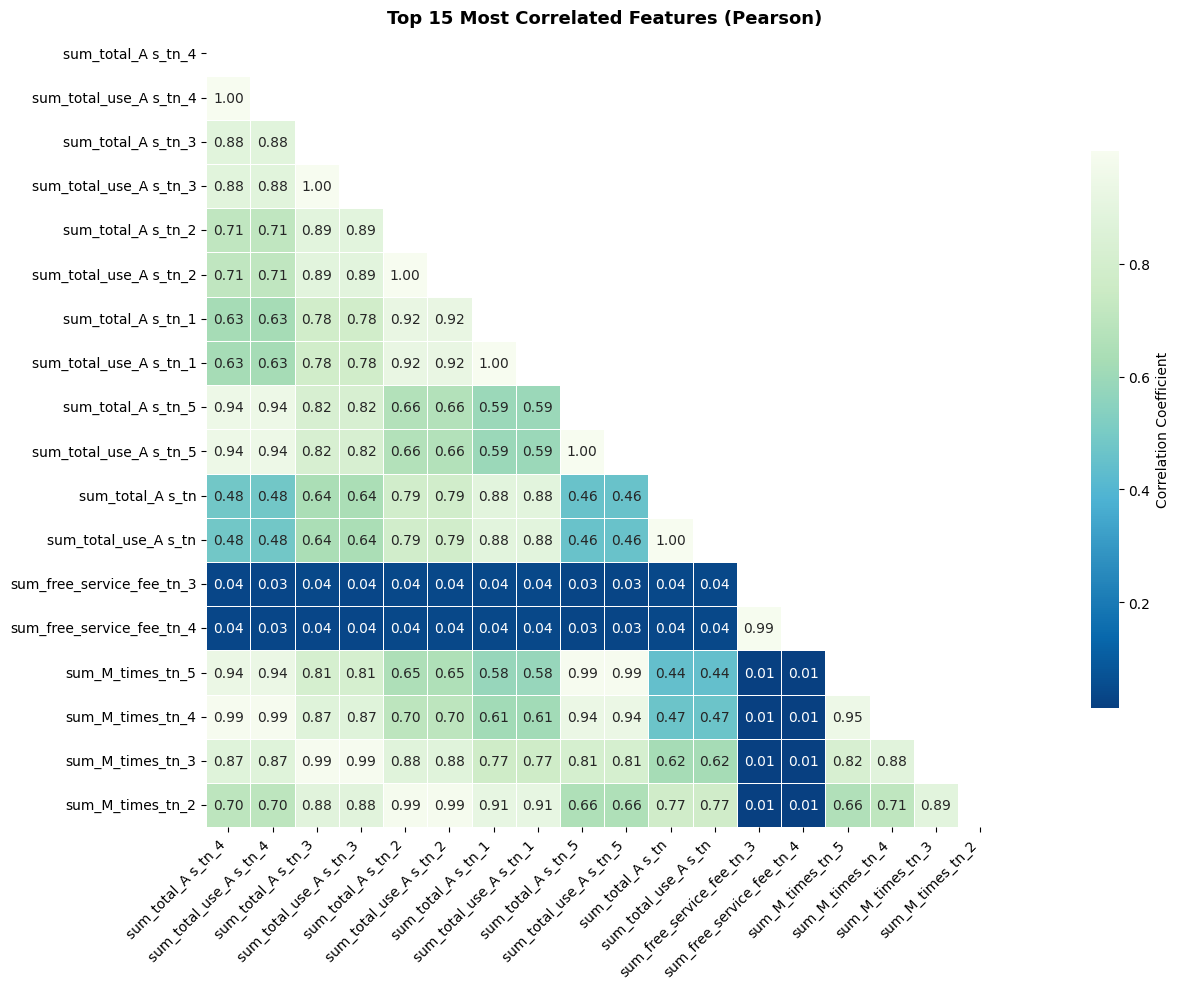

🔻 Suggested drop candidates (Correlation > 0.9):
  - sum_t_dịch vụ B_times_tn, sum_H_charge_tn_3, sum_D_other_charge_tn_4, sum_free_service_fee_tn_3, sum_H_charge_tn_5, sum_M_times_tn_5
  - sum_E  _duration_tn_3, sum_E  _times_tn_3, sum_E _charge_tn_1, sum_t_dịch vụ B_times_tn_5, sum_total_use_A s_tn_5, sum_t_A _times_tn_3
  - sum_G _charge_tn_4, sum_H_charge_tn_4, sum_E  _times_tn_2, sum_E  _duration_tn_4, sum_E  _times_tn_4, sum_E  _times_tn_5
  - sum_E _charge_tn_2, sum_t_A_charge_tn_4, sum_E _charge_tn_4, sum_G _charge_tn, sum_free_service_fee_tn_5, sum_G  _times_tn_4
  - sum_G _charge_tn_3, sum_F _times_tn_1, sum_F _times_tn_3, sum_free_service_fee_tn_1, sum_G  _times_tn_1, sum_F _charge_tn_1
  - sum_H_charge_tn_1, sum_E  _duration_tn_5, sum_E  _duration_tn_1, sum_F _charge_tn_2, sum_M_times_tn_3, sum_total_use_A s_tn_1
  - sum_total_A s_tn_5, sum_M_times_tn_2, sum_M_times_tn, sum_F _times_tn, sum_total_use_A s_tn_2, sum_F _charge_tn_5
  - sum_E  _duration_tn_2, sum_t_A _times_tn_

In [27]:
print("=" * 10, "FEATURE CORRELATION ANALYSIS", "=" * 10)

# Compute pearson correlation coefficients
correlations = df_full.drop(columns=["churn"], errors="ignore").corr(method="pearson").abs()

# Extract feature pairs with correlation > thresold (e.g.: 0.7)
corr_pairs = (correlations.where(np.triu(np.ones(correlations.shape), k = 1).astype(bool))
              .stack()
              .reset_index())
corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]

# Sort correlation values descending
top_corr = corr_pairs.sort_values(by = "Correlation", ascending = False)

# Sort correlations in descending order
top_corr = corr_pairs.sort_values(by="Correlation", ascending=False).reset_index(drop=True)

# Display top correlated pairs
N = 15
print(f"🔹 Top {N} most correlated feature pairs:")
print(top_corr.head(N))

# Create a heatmap with the mask and correct aspect ratio
# Get the top correlated feature names for pivoting
selected_features = pd.unique(top_corr.head(N)[["Feature_1", "Feature_2"]].values.ravel())

# Create a sub-correlation matrix for those features
corr_subset = correlations.loc[selected_features, selected_features]

# Create a mask with the same shape as the subset
mask = np.triu(np.ones_like(corr_subset, dtype=bool))

# Plot heatmap for these top features
plt.figure(figsize=(18, 10))
sns.heatmap(
    corr_subset,
    mask=mask,
    cmap="GnBu_r",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.7, "label": "Correlation Coefficient"},
)

plt.title(f"Top {N} Most Correlated Features (Pearson)", fontsize=13, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Suggest dropping redundant features
threshold = 0.9
drop_candidates = set(top_corr[top_corr["Correlation"] > threshold]["Feature_2"])

print(f"🔻 Suggested drop candidates (Correlation > {threshold}):")
if drop_candidates:
  # Group features per line (e.g: 6 per line)
  items_per_line = 6
  drop_candidates_list = list(drop_candidates) # Convert set to list
  for i in range(0, len(drop_candidates_list), items_per_line):
    line = ", ".join(drop_candidates_list[i:i + items_per_line])
    print(f"  - {line}")
  print(f"Total: {len(drop_candidates)} features above {threshold}")
else:
  print("  - No strong correlations found about threshold.")

print("=" * 10, "CORRELATION ANALYSIS COMPLETED", "=" * 10)

In [28]:
print("=" * 10, "DATA VALIDATION SUMMARY", "=" * 10)

# Perform automated data validation checks on the dataset
validation_results = {
    "Rows" : len(df_full),
    "Columns" : len(df_full.columns),
    "Missing values": df_full.isnull().sum().sum(),
    "Missing columns" : df_full.columns[df_full.isnull().any()].tolist(),
    "Constant columns": len((df_full.nunique() <= 1).tolist()),
    "Numeric columns" : len(df_full.select_dtypes(include=[np.number]).columns),
    "Categorical columns" : len(df_full.select_dtypes(include=['object']).columns)
}

# Convert the dictionary to a Series, then to a DataFrame with keys as index
print(pd.DataFrame.from_dict(validation_results, orient='index', columns=['Value']))

# Find features to remove
constants_feautres = [col for col in df_full.columns if df_full[col].nunique() <= 1]
high_missing_features = [col for col in df_full.columns if df_full[col].isnull().sum() / len(df_full) > 0.85]
correlation_features = list(drop_candidates)
features_to_remove = list(set(high_missing_features + constants_feautres + correlation_features))

print(f"\nChecking features")
print(f"Constants features: {len(constants_feautres)}")
print(f"High missing features: {len(high_missing_features)}")
print(f"Correlation features: " + str(len(correlation_features)))
print(f"Total features to remove: {len(features_to_remove)}")

# Remove the features
original_shape = df_full.shape
df = df_full.drop(columns=features_to_remove, errors = "ignore")
print(f"Shape: {original_shape} → {df.shape}")

# Remove the duplicates. These features have not survived.
modeling_features = []
for features_list in feature_groups.values():
  modeling_features.extend(features_list)

modeling_features = [col for col in modeling_features if col not in features_to_remove]

# Classify for type of data
numeric_features = [f for f in modeling_features if f in df.select_dtypes(include=[np.number]).columns]
categorical_features = [f for f in modeling_features if f in df.select_dtypes(include=['object']).columns]

# Result
print(f"\nFinal features after processing data")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Save variables
remaining_features = numeric_features + categorical_features
print(f"Remaining features: {len(remaining_features)}")

========== DATA VALIDATION SUMMARY ==========
                      Value
Rows                 919361
Columns                 153
Missing values            0
Missing columns          []
Constant columns        153
Numeric columns         153
Categorical columns       0

Checking features
Constants features: 0
High missing features: 0
Correlation features: 82
Total features to remove: 82
Shape: (919361, 153) → (919361, 71)

Final features after processing data
Numeric features: 71
Categorical features: 0
Remaining features: 71


========== SKEWNESS AND KURTOSIS ANALYSIS ==========
GROUP: ID (1 features)
                 ID
count  9.193610e+05
mean   1.570801e+09
std    2.171216e+09
min    1.770004e+08
25%    7.064648e+08
50%    7.952099e+08
75%    8.696279e+08
max    9.979499e+09


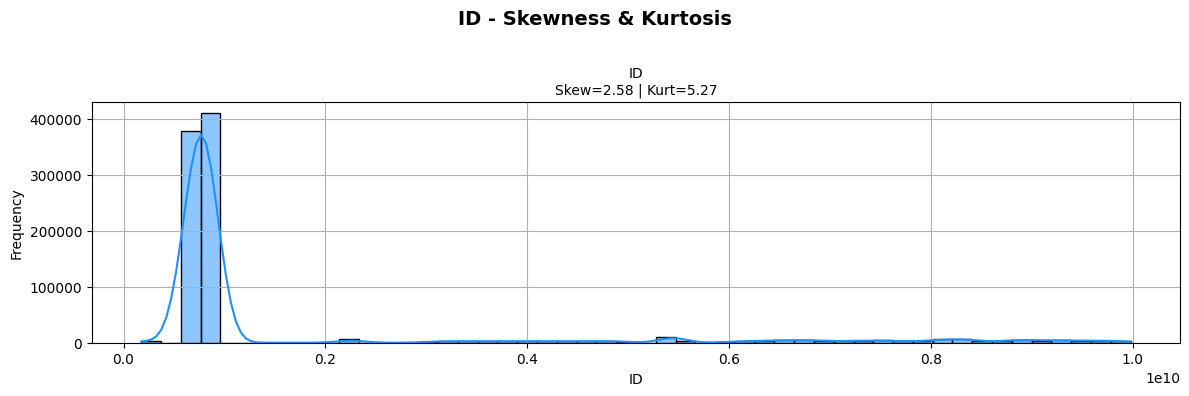

GROUP: DEMOGRAPHIC (1 features)
       customer_age
count     919361.00
mean          34.75
std            3.02
min           30.00
25%           32.00
50%           35.00
75%           37.00
max           40.00


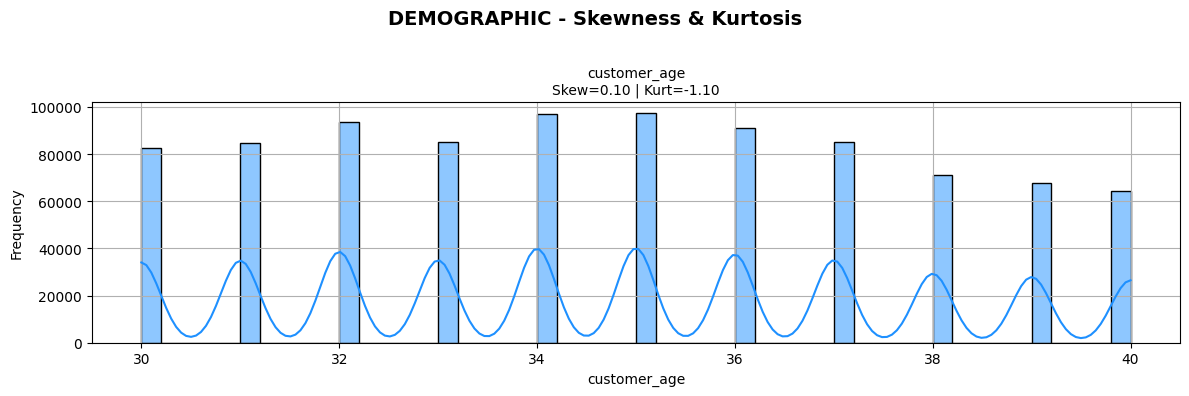

GROUP: USAGE (10 features)
       sum_total_use_charge_tn  sum_total_use_charge_tn_1  \
count                919361.00                  919361.00   
mean                 208455.04                  211684.78   
std                  210607.99                  213304.75   
min                       0.00                    -272.73   
25%                  109698.19                  111315.47   
50%                  162877.29                  165482.52   
75%                  251938.28                  254894.13   
max                99624639.30                99555007.82   

       sum_total_use_charge_tn_2  sum_total_use_charge_tn_3  \
count               9.193610e+05               9.193610e+05   
mean                2.106786e+05               2.169525e+05   
std                 2.230109e+05               2.185888e+05   
min                 0.000000e+00               0.000000e+00   
25%                 1.112850e+05               1.121504e+05   
50%                 1.650394e+05             

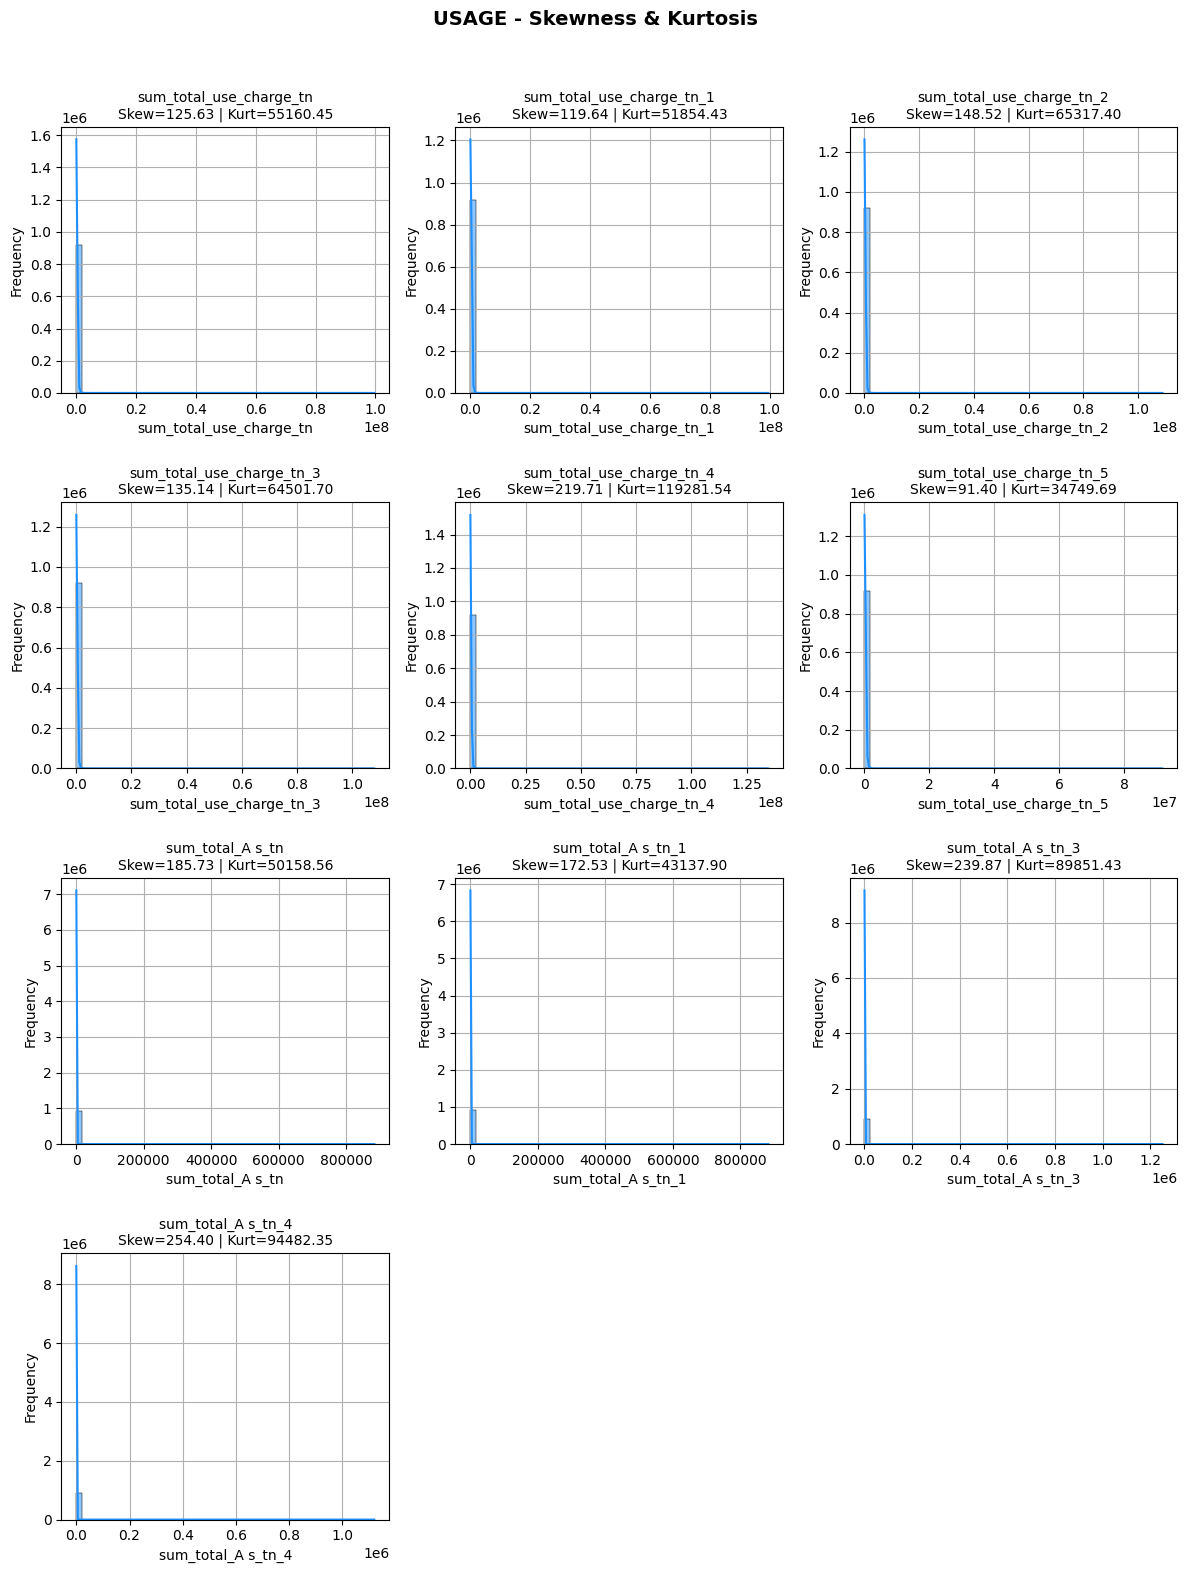

GROUP: CHARGE (25 features)
       sum_free_service_fee_tn  sum_t_A_charge_tn  sum_t_A_charge_tn_5  \
count                919361.00          919361.00            919361.00   
mean                  87035.43           59020.75             62507.99   
std                   63985.82          147373.05            146256.43   
min                       0.00               0.00                 0.00   
25%                   63636.36            5430.00              5730.00   
50%                   90909.09           23670.00             24975.00   
75%                   90909.09           68176.20             72240.00   
max                 1363636.36        99511002.93          91661808.27   

       sum_t_dịch vụ B_charge_tn  sum_t_dịch vụ B_charge_tn_1  \
count                  919361.00                    919361.00   
mean                    16480.05                     17221.80   
std                     35665.22                     36195.24   
min                     -7727.27             

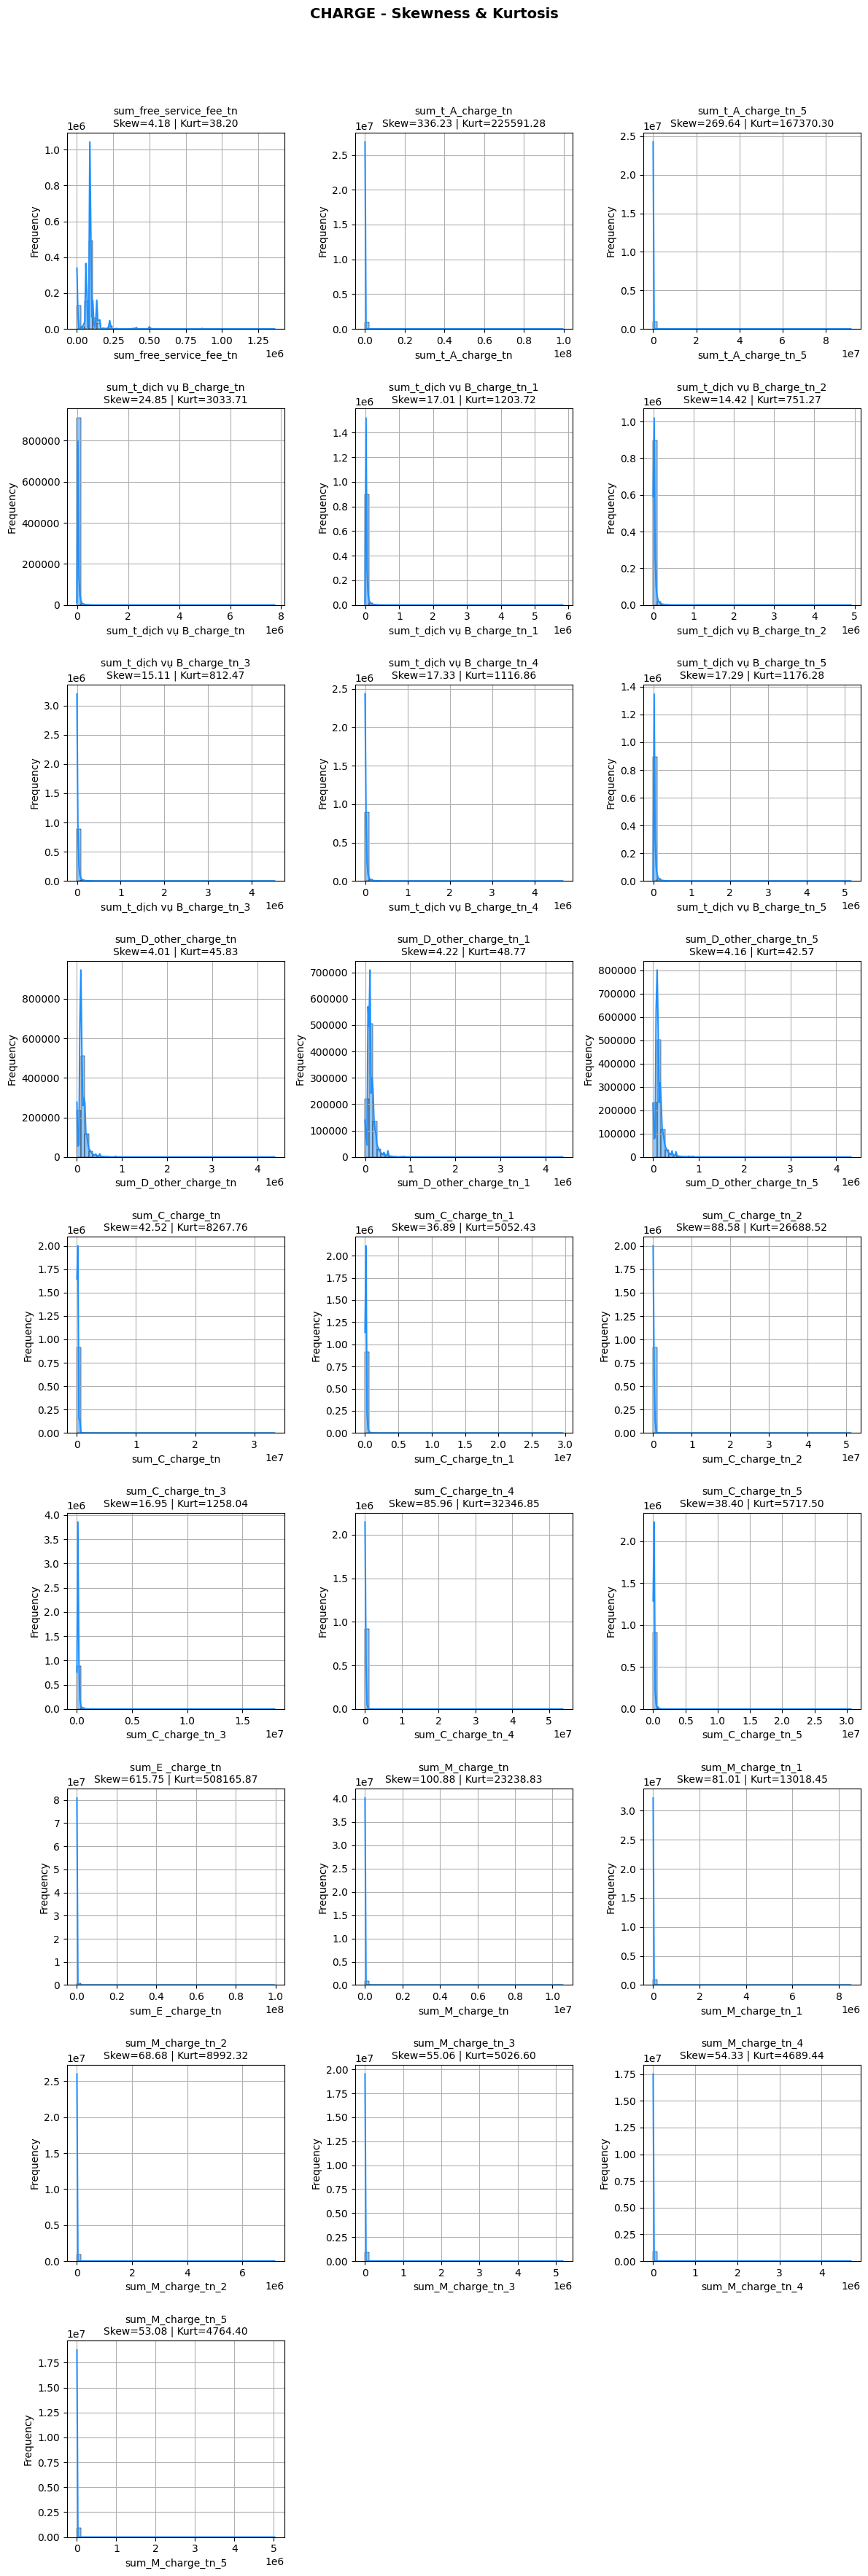

GROUP: VOLUME (6 features)
       sum_M_volume_tn  sum_M_volume_tn_1  sum_M_volume_tn_2  \
count     9.193610e+05       9.193610e+05       9.193610e+05   
mean      2.185891e+09       2.179904e+09       1.997559e+09   
std       4.342805e+09       4.370516e+09       4.017736e+09   
min       0.000000e+00       0.000000e+00       0.000000e+00   
25%       0.000000e+00       0.000000e+00       0.000000e+00   
50%       1.471606e+08       1.462659e+08       1.226604e+08   
75%       3.254381e+09       3.244874e+09       2.892323e+09   
max       2.506955e+11       2.533731e+11       2.444894e+11   

       sum_M_volume_tn_3  sum_M_volume_tn_4  sum_M_volume_tn_5  
count       9.193610e+05       9.193610e+05       9.193610e+05  
mean        1.516975e+09       1.451353e+09       1.427577e+09  
std         3.349771e+09       3.218548e+09       3.213804e+09  
min         0.000000e+00       0.000000e+00       0.000000e+00  
25%         0.000000e+00       0.000000e+00       0.000000e+00  
50%   

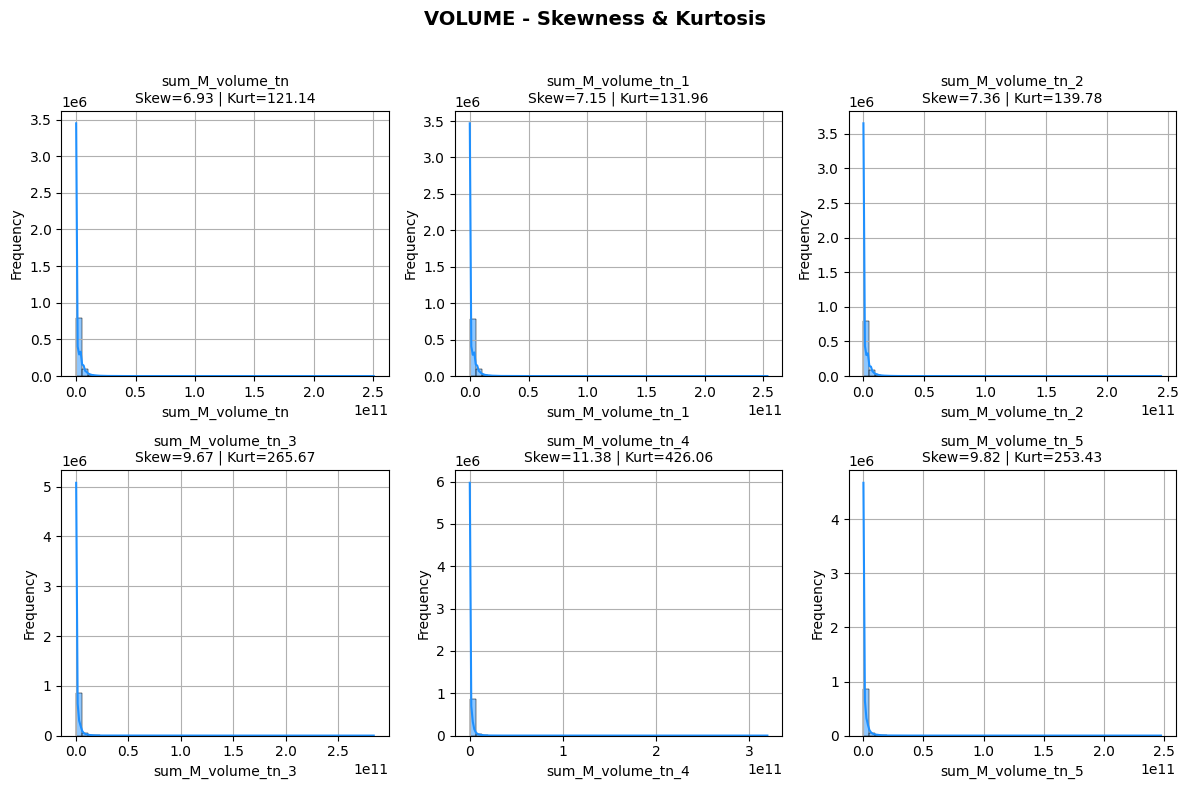

GROUP: TIMES (15 features)
       sum_t_A _times_tn  sum_C_times_tn  sum_C_times_tn_1  sum_C_times_tn_2  \
count          919361.00       919361.00         919361.00         919361.00   
mean              316.44            3.53              3.61              3.59   
std               278.40           31.59             38.28             29.95   
min                 0.00            0.00              0.00              0.00   
25%               138.00            1.00              1.00              1.00   
50%               256.00            2.00              2.00              2.00   
75%               421.00            3.00              3.00              3.00   
max             67429.00        16135.00          20664.00          15699.00   

       sum_C_times_tn_3  sum_C_times_tn_4  sum_C_times_tn_5  sum_G  _times_tn  \
count         919361.00         919361.00         919361.00         919361.00   
mean               3.49              3.45              3.47             54.06   
std      

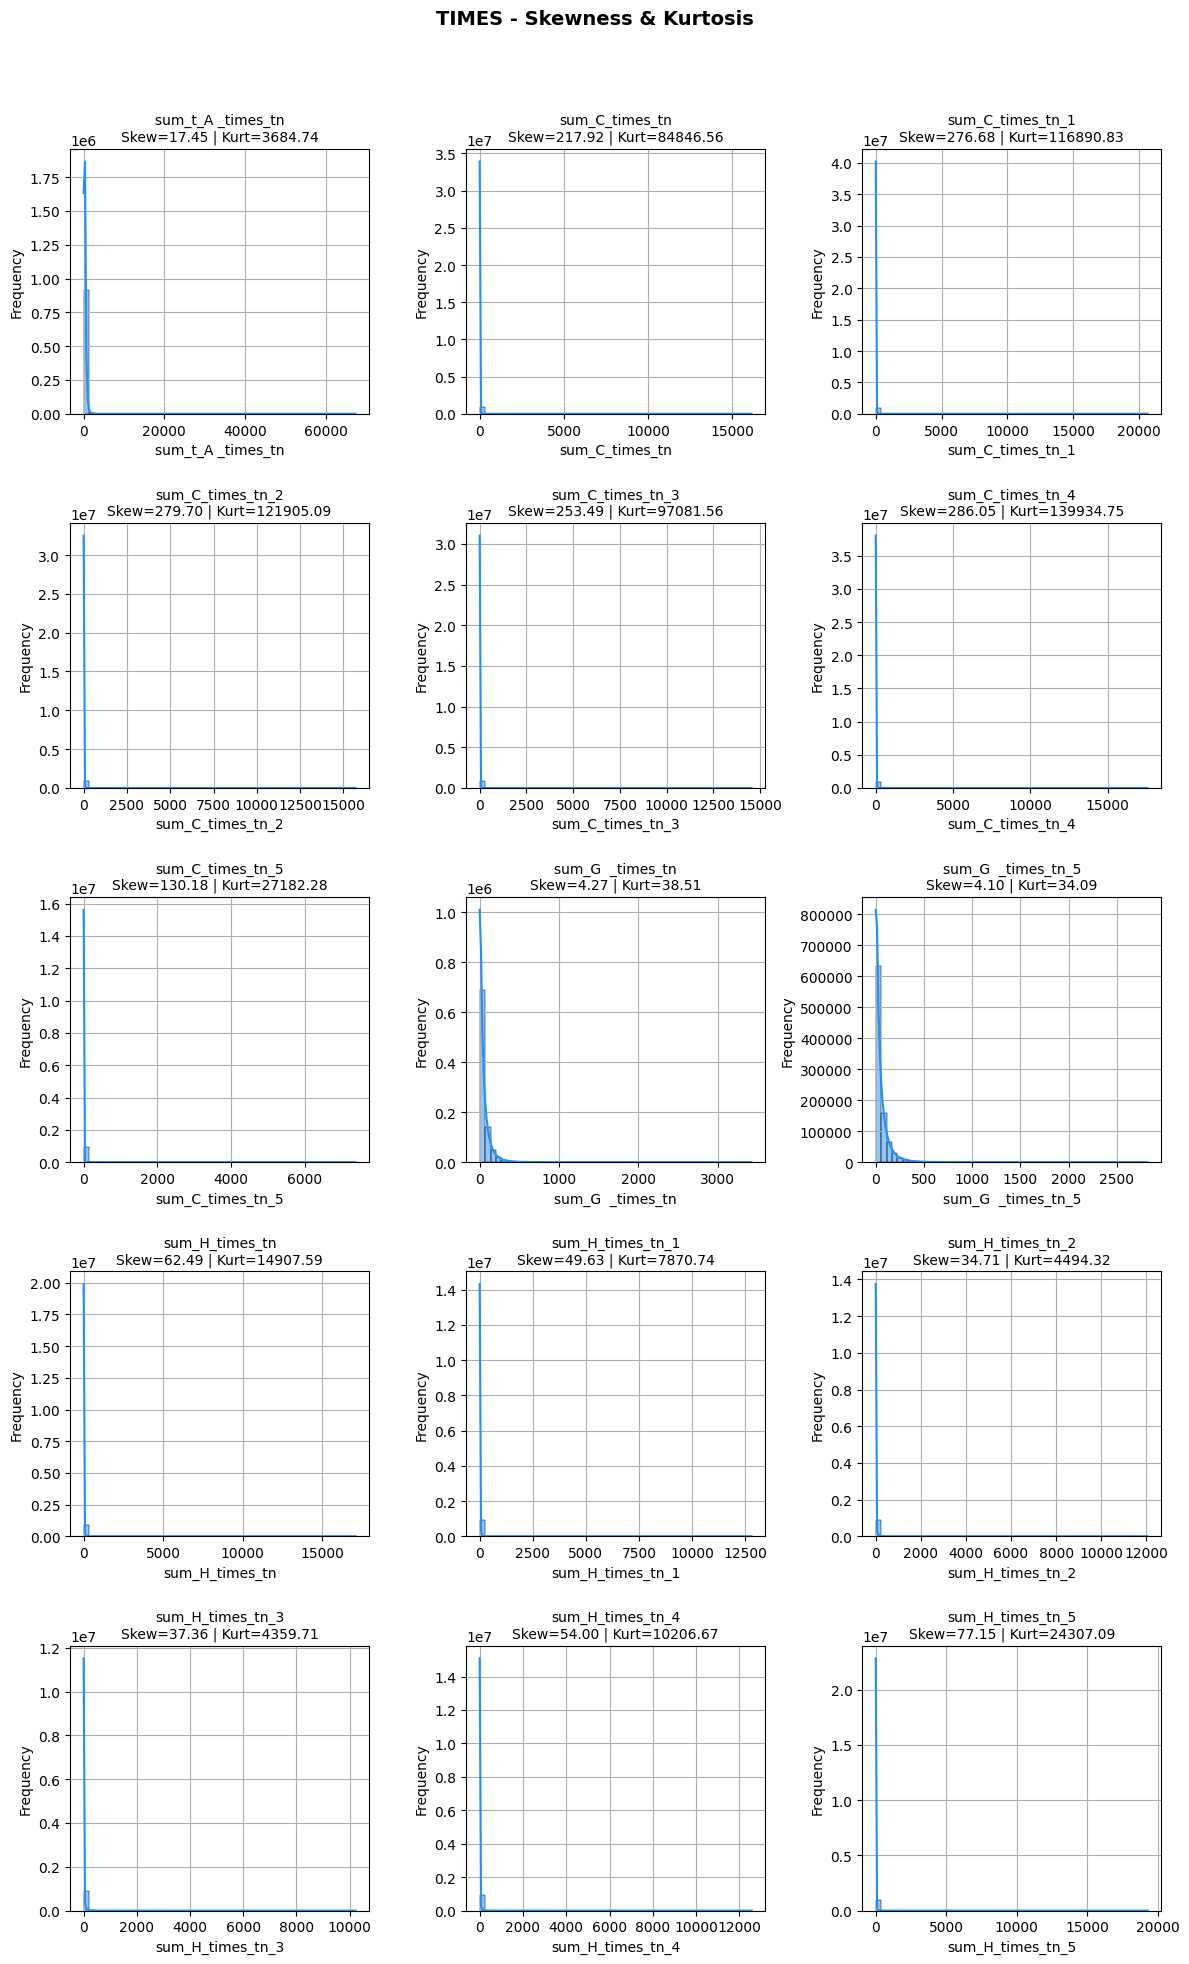

GROUP: DURATION (12 features)
       sum_t_A _duration_tn  sum_t_A _duration_tn_1  sum_t_A _duration_tn_2  \
count             919361.00               919361.00               919361.00   
mean               22237.21                22641.25                22736.28   
std                20739.19                20731.08                20901.20   
min                    0.00                    0.00                    0.00   
25%                 8717.00                 9127.00                 9298.00   
50%                17374.00                17821.00                17974.00   
75%                30586.00                31049.00                31121.00   
max              7374735.00              7372266.00              8064935.00   

       sum_t_A _duration_tn_3  sum_t_A _duration_tn_4  sum_t_A _duration_tn_5  \
count               919361.00               919361.00               919361.00   
mean                 24286.21                23500.11                23914.67   
std            

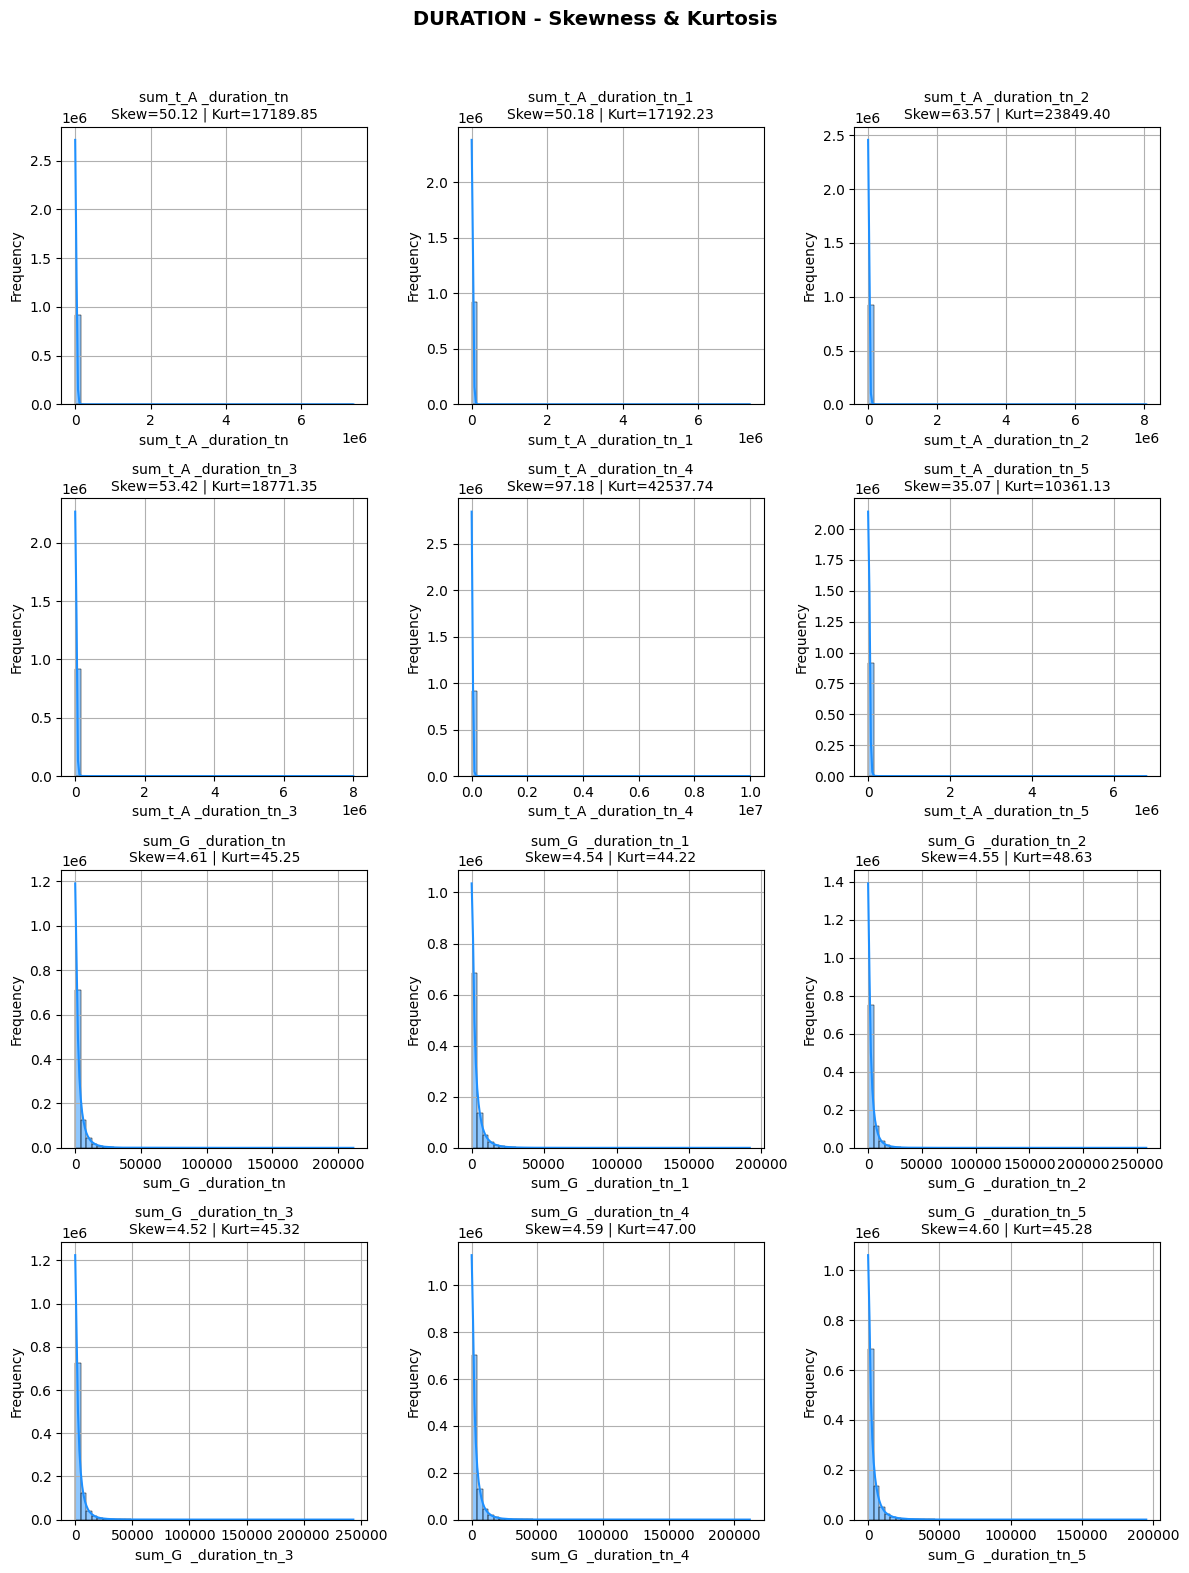

Skipping empty group: Temporal
No numeric features to describe in this group (excluding target and dropped features).
Group 'Target': no numeric features — skipped.
Skipping empty group: Other
========== SUMMARY ANALYSIS COMPLETED ==========


In [29]:
# FUNCTION 1: COMPUTE SKEWNESS AND KURTOSIS
def compute_skew_kurt(df, features, target_col, drop_candidates=None):
  """Compute skewness, kurtosis and suggest normalization scaler"""
  if drop_candidates is None:
    drop_candidates = []

  valid_features = [c for c in features if c not in drop_candidates and c != target_col]
  numeric_cols = df[valid_features].select_dtypes(include=[np.number]).columns

  if numeric_cols.empty:
      print("No numeric features to describe in this group (excluding target and dropped features).")
      return pd.DataFrame(columns=["Feature", "Skewness", "Kurtosis", "Suggested_Scaler"])

  # Compute skewness and kurtosis
  skew_kurt = pd.DataFrame({
      "Feature": numeric_cols,
      "Skewness": df[numeric_cols].skew(),
      "Kurtosis": df[numeric_cols].kurtosis()
  }).reset_index(drop=True)

  # Suggest scaler
  def normalization_summary(rows):
    skew, kurt = abs(rows["Skewness"]), abs(rows["Kurtosis"])
    if skew > 2 and kurt > 7:
      return "Log Transform"
    elif 1 < skew < 2 and 3 < kurt <= 7:
      return "RobustScaler"
    else:
      return "StandardScaler"

  skew_kurt["Suggested_Scaler"] = skew_kurt.apply(normalization_summary, axis=1)
  return skew_kurt

# FUNCTION 2: PLOT GROUP HISTOGRAMS
def plot_skew_kurt_group(df, group_name, cols, skew_kurt_summary):
  """
  Plot histograms for each numeric feature in the group
  Automatically hides empty subplots
  """
  # Filter group columns to only include those present in the skew_kurt_summary
  group_cols = [c for c in cols if c in skew_kurt_summary["Feature"].values]
  if not group_cols:
    print(f"Group '{group_name}': no numeric features \u2014 skipped.")
    return

  print(f"GROUP: {group_name.upper()} ({len(group_cols)} features)")
  print(df[group_cols].describe().round(2)) # Changed numeric_cols to group_cols

  n_features = len(group_cols)
  if n_features > 0:
    n_cols = min(3, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize = (12, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(group_cols):
      ax = axes[i]
      sns.histplot(df[col], kde=True, bins=50, ax=ax, color="DodgerBlue", edgecolor="black")
      skew = skew_kurt_summary.loc[skew_kurt_summary["Feature"] == col, "Skewness"].values[0]
      kurt = skew_kurt_summary.loc[skew_kurt_summary["Feature"] == col, "Kurtosis"].values[0]
      ax.set_title(f"{col}\nSkew={skew:.2f} | Kurt={kurt:.2f}", fontsize=10)
      ax.set_xlabel(col) # Changed from "Value" to `col`
      ax.set_ylabel("Frequency")
      ax.grid()

    # Hide unused subplots
    for j in range(n_features, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"{group_name.upper()} - Skewness & Kurtosis", fontsize=14, weight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# MAIN LOOP \u2014 EXECUTION CONTROL
print("=" * 10, "SKEWNESS AND KURTOSIS ANALYSIS", "=" * 10)

# Assume we already have feature_groups and TARGET ('churn')
TARGET = 'churn'

for group_name, features_list in feature_groups.items(): # Corrected from summary_data.items()
    if not features_list:
        print(f"Skipping empty group: {group_name}")
        continue

    # Compute stats for this specific group
    # Corrected arguments for compute_skew_kurt
    skew_kurt_summary = compute_skew_kurt(df, features_list, TARGET, features_to_remove)

    # Plot histogram + scaler info
    # Corrected arguments for plot_skew_kurt_group
    plot_skew_kurt_group(df, group_name, features_list, skew_kurt_summary)

print("=" * 10, "SUMMARY ANALYSIS COMPLETED", "=" * 10)

📊 Analyzing top 5 numeric features vs churn

🔹 Feature: ID
Mean (0): 1567638272.105, Std(0): 2167448492.234
Mean (1): 1691479811.721, Std(1): 2307225417.580
➤ Mann–Whitney p = 3.276e-19
➤ KS test p      = 1.710e-52
⭐ Highly significant difference


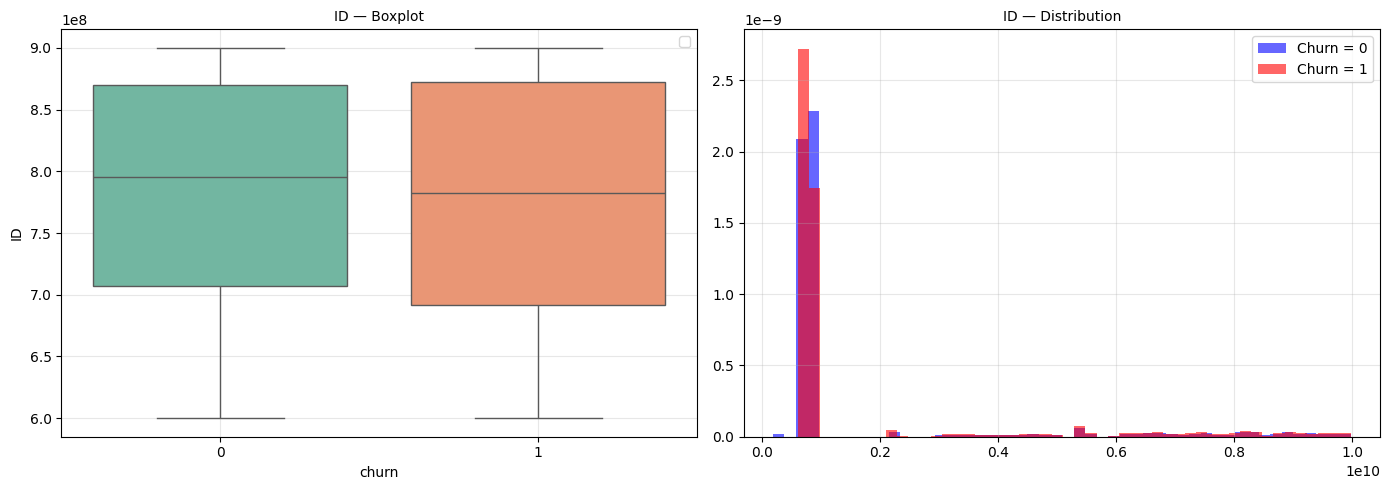

🔹 Feature: customer_age
Mean (0): 34.751, Std(0): 3.023
Mean (1): 34.551, Std(1): 3.036
➤ Mann–Whitney p = 6.305e-24
➤ KS test p      = 4.599e-16
⭐ Highly significant difference


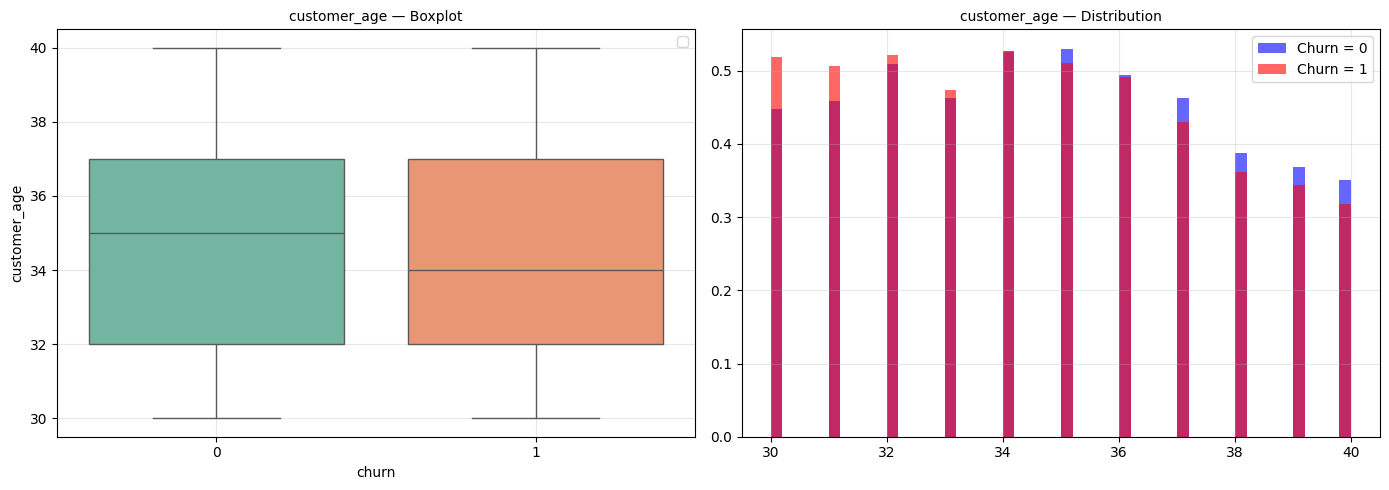

🔹 Feature: sum_total_use_charge_tn
Mean (0): 211031.991, Std(0): 211857.085
Mean (1): 110118.346, Std(1): 119565.402
➤ Mann–Whitney p = 0.000e+00
➤ KS test p      = 0.000e+00
⭐ Highly significant difference


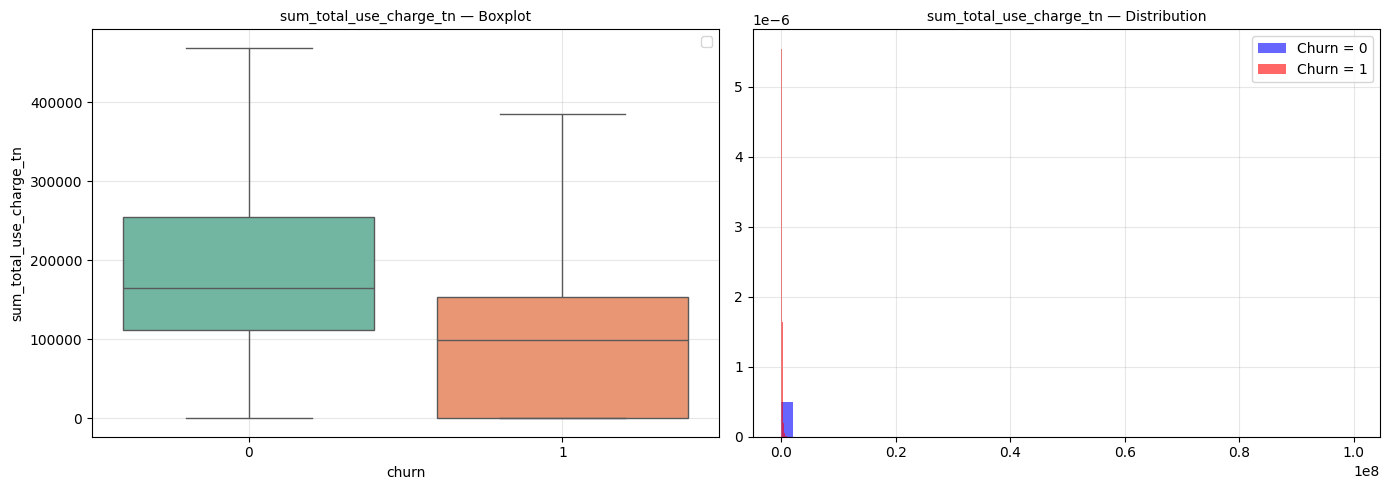

🔹 Feature: sum_total_use_charge_tn_1
Mean (0): 212438.229, Std(0): 214512.189
Mean (1): 182933.175, Std(1): 157922.795
➤ Mann–Whitney p = 9.060e-308
➤ KS test p      = 1.131e-220
⭐ Highly significant difference


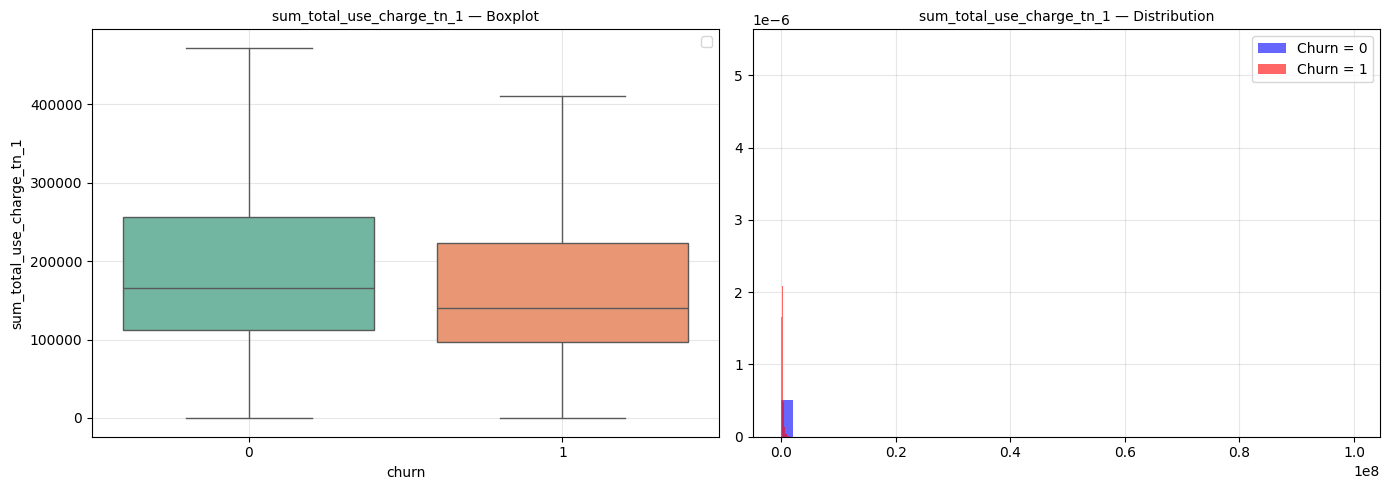

🔹 Feature: sum_total_use_charge_tn_2
Mean (0): 211137.659, Std(0): 224052.656
Mean (1): 193162.753, Std(1): 177900.466
➤ Mann–Whitney p = 2.813e-131
➤ KS test p      = 1.553e-103
⭐ Highly significant difference


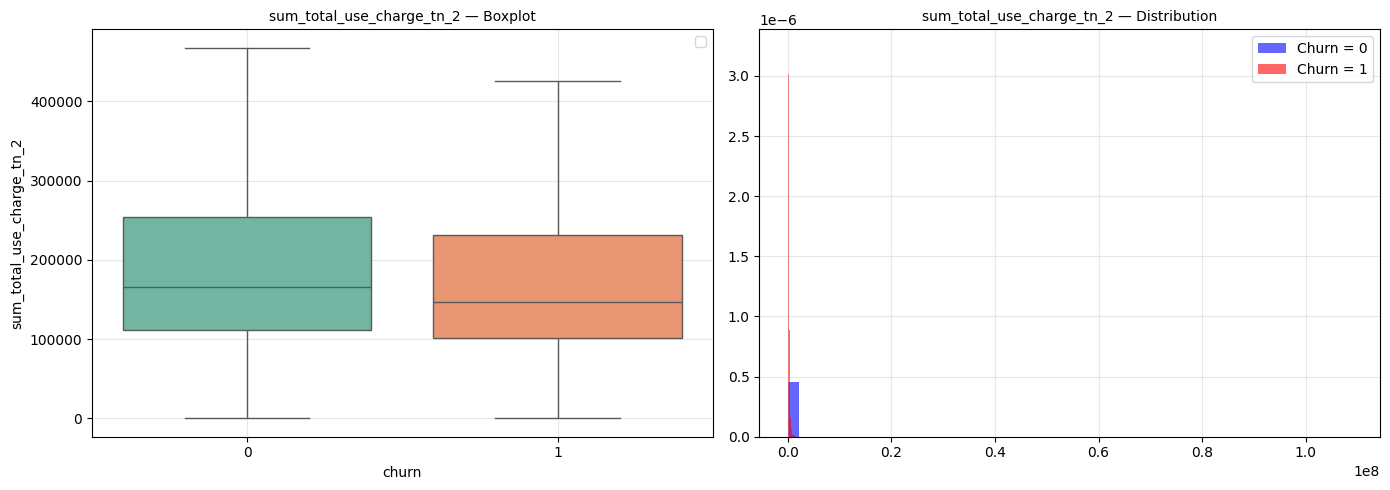

In [30]:
def analyze_numeric_features(df, target, features, max_features=5):
    """
    - features: list features còn lại sau khi lọc tương quan (remaining_features)
    - max_features: số features quan trọng nhất
    """
    numeric_feats = df[features].select_dtypes(include=[np.number]).columns.tolist()
    numeric_feats = numeric_feats[:max_features]

    print(f"📊 Analyzing top {len(numeric_feats)} numeric features vs {target}\n")

    for feature in numeric_feats:
        group0 = df[df[target] == 0][feature]
        group1 = df[df[target] == 1][feature]

        # --- Statistical tests ---
        mw_stat, mw_p = mannwhitneyu(group0, group1, alternative="two-sided")
        ks_stat, ks_p = ks_2samp(group0, group1)

        print(f"🔹 Feature: {feature}")
        print(f"Mean (0): {group0.mean():.3f}, Std(0): {group0.std():.3f}")
        print(f"Mean (1): {group1.mean():.3f}, Std(1): {group1.std():.3f}")
        print(f"➤ Mann–Whitney p = {mw_p:.3e}")
        print(f"➤ KS test p      = {ks_p:.3e}")

        if mw_p < 0.001:
            print("⭐ Highly significant difference")
        elif mw_p < 0.05:
            print("✔ Statistically significant")
        else:
            print("❌ No significant difference between groups")

        # --- Visualization ---
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))

        # Boxplot
        sns.boxplot(data=df, x=target, y=feature, ax=ax[0], palette="Set2", showfliers=False)
        ax[0].set_title(f"{feature} — Boxplot",  fontsize = 10)
        ax[0].legend()
        ax[0].grid(alpha=0.3)

        ax[1].hist(group0, bins=50, alpha=0.6, label="Churn = 0", density=True, color="blue")
        ax[1].hist(group1, bins=50, alpha=0.6, label="Churn = 1", density=True, color="red")
        ax[1].set_title(f"{feature} — Distribution", fontsize = 10)
        ax[1].legend()
        ax[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

top_numeric_features = remaining_features[:5]
analyze_numeric_features(df_full, target="churn", features=top_numeric_features)

In [31]:
print("=" * 10, "OUTLIER DETECTION (IQR METHOD)", "=" * 10)

TARGET = "churn"

numeric_cols = df_full.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c.lower() not in ["id", TARGET]]

outlier_summary = {}

for col in numeric_cols:
    Q1, Q3 = df_full[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    outlier_count = ((df_full[col] < lower) | (df_full[col] > upper)).sum()
    outlier_summary[col] = outlier_count

summary_df = pd.DataFrame({
    "Feature": list(outlier_summary.keys()),
    "Outlier Count": list(outlier_summary.values())
})
summary_df["Outlier %"] = (summary_df["Outlier Count"] / len(df_full) * 100).round(2)
summary_df = summary_df.sort_values("Outlier Count", ascending=False)

print("Top 20 features with most outliers:")
display(summary_df.head(20))

========== OUTLIER DETECTION (IQR METHOD) ==========
Top 20 features with most outliers:


,Feature,Outlier Count,Outlier %
12,sum_free_service_fee_tn,250859,27.29
13,sum_free_service_fee_tn_1,244331,26.58
14,sum_free_service_fee_tn_2,243912,26.53
15,sum_free_service_fee_tn_3,241339,26.25
16,sum_free_service_fee_tn_4,240089,26.11
17,sum_free_service_fee_tn_5,238873,25.98
102,sum_E _charge_tn_5,179476,19.52
100,sum_E _charge_tn_3,176560,19.20
98,sum_E _charge_tn_1,173299,18.85
101,sum_E _charge_tn_4,172833,18.80


In [32]:
print("\n" + "=" * 10, "FEATURE LEAKAGE DETECTION", "=" * 10)

leakage = []

# A) Suspicious column names
danger_words = ["next", "future", "after", "post", "label", "churn"]
for col in df_full.columns:
    if any(w in col.lower() for w in danger_words):
        leakage.append((col, "Suspicious name pattern"))

# B) High correlation with target
corr_target = df_full.corr(numeric_only=True)[TARGET].abs()
high_corr = corr_target[corr_target > threshold].index.tolist()

for col in high_corr:
    if col != TARGET:
        leakage.append((col, "Correlation > 0.9 with target"))

# C) Binary identical to target
for col in numeric_cols:
    if df_full[col].nunique() == 2:
        if df_full[col].corr(df_full[TARGET]) > 0.95:
            leakage.append((col, "Binary duplicate of target"))

leakage_df = pd.DataFrame(leakage, columns=["Feature", "Reason"]).drop_duplicates()

print("\n⚠️ Potential leakage features:")
display(leakage_df if not leakage_df.empty else "No leakage found")

print("\n" + "=" * 10, "FILTER REMAINING FEATURES", "=" * 10)

# 1) Remove leakage features
leakage_list = leakage_df["Feature"].tolist() if not leakage_df.empty else []

# 2) Remove highly correlated features among predictors
corr_matrix = df_full[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_corr = [
    col for col in upper.columns
    if any(upper[col] > threshold)
]

# 3) Final filtering
final_features = [
    col for col in numeric_cols
    if col not in leakage_list and col not in to_drop_corr
]

print(f"Final usable features: {len(final_features)}")
print(textwrap.fill(', '.join(final_features[:30]), width = 200), "... (truncated)")



========== FEATURE LEAKAGE DETECTION ==========

⚠️ Potential leakage features:


,Feature,Reason
0,churn,Suspicious name pattern



========== FILTER REMAINING FEATURES ==========
Final usable features: 69
sum_total_use_charge_tn, sum_total_use_charge_tn_1, sum_total_use_charge_tn_2, sum_total_use_charge_tn_3, sum_total_use_charge_tn_4, sum_total_use_charge_tn_5, sum_total_A s_tn, sum_total_A s_tn_1,
sum_total_A s_tn_3, sum_total_A s_tn_4, sum_free_service_fee_tn, sum_t_A_charge_tn, sum_t_A_charge_tn_5, sum_t_dịch vụ B_charge_tn, sum_t_dịch vụ B_charge_tn_1, sum_t_dịch vụ B_charge_tn_2, sum_t_dịch
vụ B_charge_tn_3, sum_t_dịch vụ B_charge_tn_4, sum_t_dịch vụ B_charge_tn_5, sum_t_A _times_tn, sum_t_A _duration_tn, sum_t_A _duration_tn_1, sum_t_A _duration_tn_2, sum_t_A _duration_tn_3, sum_t_A
_duration_tn_4, sum_t_A _duration_tn_5, customer_age, sum_D_other_charge_tn, sum_D_other_charge_tn_1, sum_D_other_charge_tn_5 ... (truncated)


# 2. Feature Engineering and Processing

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler

# Create train and test sets
print("DATA PREPARATION FOR MODELING")

X = df_full[final_features].select_dtypes(include=[np.number]).copy()
y = df_full[TARGET].copy()

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"Train shape: X = {x_train.shape}, y = {y_train.shape}, churn_rate = {y_train.mean():.4f}")
print(f"Test shape: X = {x_test.shape}, y = {y_test.shape}, churn_rate = {y_test.mean():.4f}")

# Check missing values
train_missing = x_train.isnull().sum().sum()
test_missing = x_test.isnull().sum().sum()

print(f"Total missing values in train: {train_missing.sum()}")
print(f"Total missing values in test: {test_missing.sum()}")

# Handle any remaining missing values (should be rare at this point)
if train_missing > 0 or test_missing > 0:
    print("Handling remaining missing values...")
    # Impute categorical with 'UNKNOWN'
    for col in categorical_features:
        if x_train[col].isnull().sum() > 0:
            x_train[col] = x_train[col].fillna('UNKNOWN')
        if x_test[col].isnull().sum() > 0:
            x_test[col] = x_test[col].fillna('UNKNOWN')

    # Impute numeric with median
    for col in numeric_features:
        if x_train[col].isnull().sum() > 0:
            median_val = x_train[col].median()
            x_train[col] = x_train[col].fillna(median_val)
            x_test[col] = x_test[col].fillna(median_val)  # Use train median for test too


# Đảm bảo kiểu dữ liệu đúng cho categorical features
for col in categorical_features:
    x_train[col] = x_train[col].astype(str)
    x_test[col] = x_test[col].astype(str)

# Create simple and reliable processor
class LogTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        return np.log1p(X - X.min() + 1)

# Define feature lists for preprocessing
# Assuming all final_features will be scaled by StandardScaler for now
# As specific log_features and robust_features were not defined in previous cells
standard_features = final_features

preprocessor = ColumnTransformer(
    transformers=[
        ("standard_scaling", StandardScaler(), standard_features)
    ],
    remainder="drop"
)


DATA PREPARATION FOR MODELING
Train shape: X = (735488, 69), y = (735488,), churn_rate = 0.0255
Test shape: X = (183873, 69), y = (183873,), churn_rate = 0.0255
Total missing values in train: 0
Total missing values in test: 0


# 3. Model training and predict

In [34]:
def compute_model(model_name, data_imbalances, y_true, y_prob, threshold = 0.5):
  # Comprehensive evaluation for churn model
  y_pred = (y_prob >= threshold).astype(int)

  # Basic metrics
  TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred)
  recall = recall_score(y_true, y_pred)

  return

def psi_calculations(expected, actual, bins = 10):
  """
  Calculate Population Stability Index (PSI) with handling for duplicate bin edges
  PSI < 0.1: Stable
  0.1 <= PSI < 0.25: Monitor required
  PSI >= 0.25: Investigate required
  """
  # Define breakpoints using quantiles from the expected distribution
  breakpoints_quantiles = np.linspace(0, 1, bins + 1)
  bin_edges = np.unique(np.quantile(expected, breakpoints_quantiles))

  # Add -inf and inf to cover all values
  bin_edges = np.concatenate([[-np.inf], bin_edges, [np.inf]])

  # Calculate the distribution (counts) for expected and actual data within these bins
  expected_counts = np.histogram(expected, bins=bin_edges)[0]
  actual_counts = np.histogram(actual, bins=bin_edges)[0]

  # Convert counts to percentages
  expected_percent = expected_counts / len(expected)
  actual_percent = actual_counts / len(actual)

  # Add a small constant to zero percentages to avoid log(0) and division by zero
  epsilon = 1e-6
  expected_percent = np.where(expected_percent == 0, epsilon, expected_percent)
  actual_percent = np.where(actual_percent == 0, epsilon, actual_percent)

  # Apply the PSI formula
  psi_value = np.sum((expected_percent - actual_percent) * np.log(expected_percent / actual_percent))
  return psi_value

**Model Selection**

In [35]:
# ================================
# 1️⃣ DEFINE MODELS
# ================================
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=150, n_jobs=-1),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300)
}

if has_xgb:
    models["XGBoost"] = XGBClassifier(
        n_estimators=150,
        eval_metric="logloss",
        tree_method="hist"
    )

# ================================
# 2️⃣ CROSS-VALIDATION LOOP
# ================================
N_SPLITS = 5
kfold = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

results = []
calibration_data = {}

print(f"Dataset: {len(X):,} rows — {X.shape[1]} features")
print("Target distribution:")
print(y.value_counts(normalize=True).round(4))


# ================================
# 3️⃣ RUN CV
# ================================
for fold_idx, (train_idx, test_idx) in enumerate(kfold.split(X, y), 1):

    print(f"\n===== FOLD {fold_idx}/{N_SPLITS} =====")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    for name, clf in models.items():

        # =====================================
        # A) NO SMOTE — BASELINE PIPELINE
        # =====================================
        pipe_nosmote = Pipeline([
            ("preprocess", preprocessor),
            ("model", clf)
        ])

        pipe_nosmote.fit(X_train, y_train)
        y_prob = pipe_nosmote.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(y_test, y_prob)
        gini = 2 * auc - 1
        mse = mean_squared_error(y_test, y_prob)

        # PSI: compare train_prob vs test_prob (NO SMOTE)
        psi = psi_calculations(
            pipe_nosmote.predict_proba(X_train)[:, 1],
            y_prob
        )

        results.append({
            "fold": fold_idx, "model": name, "balanced": False,
            "auc": auc, "gini": gini, "mse": mse, "psi": psi
        })

        print(f"[NO-SMOTE] {name:18s} AUC={auc:.4f}  GINI={gini:.3f}  "
              f"MSE={mse:.4f}  PSI={psi:.4f}")


        # =====================================
        # B) WITH SMOTE — IN PIPELINE
        # =====================================
        pipe_smote = ImbPipeline([
            ("preprocess", preprocessor),
            ("smote", SMOTE(random_state=42)),
            ("model", clf)
        ])

        pipe_smote.fit(X_train, y_train)

        y_prob_smote = pipe_smote.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(y_test, y_prob_smote)
        gini = 2 * auc - 1
        mse = mean_squared_error(y_test, y_prob_smote)

        # PSI MUST use original train prob — not SMOTE-sampled prob
        psi = psi_calculations(
            pipe_nosmote.predict_proba(X_train)[:, 1],  # baseline
            y_prob_smote
        )

        results.append({
            "fold": fold_idx, "model": name, "balanced": True,
            "auc": auc, "gini": gini, "mse": mse, "psi": psi
        })

        print(f"[SMOTE]    {name:18s} AUC={auc:.4f}  GINI={gini:.3f}  "
              f"MSE={mse:.4f}  PSI={psi:.4f}")


        # Save calibration (fold 1 only)
        if fold_idx == 1:
            calibration_data[name] = (y_test, y_prob)


# ================================
# 4️⃣ SUMMARY
# ================================
res_df = pd.DataFrame(results)
print("\n===== SUMMARY =====")
display(res_df.groupby(["model", "balanced"])[["auc", "gini", "mse", "psi"]].mean())


# ================================
# 5️⃣ CALIBRATION CURVE
# ================================
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111)

for i, (name, (yt, yp)) in enumerate(calibration_data.items()):
    CalibrationDisplay.from_predictions(
        yt, yp, n_bins=10, name=name, ax=ax
    )

ax.grid()
ax.legend()
plt.show()


Dataset: 919,361 rows — 69 features
Target distribution:
churn
0    0.9745
1    0.0255
Name: proportion, dtype: float64

===== FOLD 1/5 =====
[NO-SMOTE] LogisticRegression AUC=0.8507  GINI=0.701  MSE=0.1523  PSI=0.0001
[SMOTE]    LogisticRegression AUC=0.8520  GINI=0.704  MSE=0.1491  PSI=0.0001
[NO-SMOTE] RandomForest       AUC=0.8415  GINI=0.683  MSE=0.0164  PSI=0.3797
[SMOTE]    RandomForest       AUC=0.8543  GINI=0.709  MSE=0.0215  PSI=0.7956
[NO-SMOTE] MLP                AUC=0.8562  GINI=0.712  MSE=0.0176  PSI=0.0000
[SMOTE]    MLP                AUC=0.8427  GINI=0.685  MSE=0.0944  PSI=0.0001
[NO-SMOTE] XGBoost            AUC=0.8612  GINI=0.722  MSE=0.0159  PSI=0.0001
[SMOTE]    XGBoost            AUC=0.8650  GINI=0.730  MSE=0.0166  PSI=0.0000

===== FOLD 2/5 =====
[NO-SMOTE] LogisticRegression AUC=0.8435  GINI=0.687  MSE=0.1510  PSI=0.0001
[SMOTE]    LogisticRegression AUC=0.8453  GINI=0.691  MSE=0.1482  PSI=0.0001
[NO-SMOTE] RandomForest       AUC=0.8336  GINI=0.667  MSE=0.0167  

KeyboardInterrupt: 